# Examen Data Science & AI

| **Examenreeks**          | Reeks A |
| :---                     | :--- |
| **Student Voornaam:**    | VUL HIER JE VOORNAAM IN |
| **Student Familienaam:** | VUL HIER JE FAMILIENAAM IN |
| **Studentennummer:**     | VUL HIER JE STUDENTENNUMMER IN |
| **Datum & uur:**         | Maandag 10 juni 2024, 12:30 |
| **Klasgroep:**           | VUL HIER JE KLASGROEP IN |
| **IOEM-student:**        | NEE |

Voeg waar nodig codecellen toe voor het uitwerken van de vragen. LET OP! De inhoud van de codeblokken wordt niet als antwoord beschouwd! Enkel wat je in de daarvoor voorziene Markdown-cellen noteert telt als antwoord! De inhoud van de codeblokken dient enkel om je antwoord te staven, zodat we kunnen zien hoe je tot je antwoord gekomen bent als het niet zou overeenkomen met de verwachte uitkomst.

Het examen staat in totaal op 50 punten (wordt herrekend naar een examencijfer op 20).

In [3]:
# Importeren van de nodige packages
# Vul zelf aan met extra packages als dit nodig is voor de oefeningen!
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

C:\Users\32468\AppData\Local\Temp\ipykernel_8180\3083441694.py:4: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


----

## Vraag 1 [2 pt]

Wat is het meetniveau van elk van deze variabelen:

1. [0.5pt] de afstand thuis-werk in kilometers
2. [0.5pt] het meest frequent gebruikte vervoersmiddel om boodschappen te doen van de respondenten (te voet, per fiets, per trein, ...)
3. [0.5pt] frequentie van het gebruik van het openbaar vervoer (nooit, minder dan 1 keer per week, 1 keer per week, 2 keer per week, meer dan 2 keer per week)
4. [0.5pt] het geboortejaar van de respondenten

### Antwoord

1. ratio
2. nominaal 
3. ordinaal
4. interval

----

## Vraag 2 [3 pt]

Ziekenhuizen zijn verplicht om aan kwaliteitszorg te doen. Nadat een patiënt uit het ziekenhuis werd ontslagen na een opname, krijgt deze een e-mail. De e-mail bevat een link naar een enquête waarlangs de patiënt de gekregen zorg kan beoordelen.

1. [1pt] Is dit een aselecte steekproef/random sample? Leg uit.
2. [1pt] Welk type fout(en) wordt hier gemaakt?
3. [1pt] Is dit een goede steekproef? Leg uit.

### Antwoord

1. Dit is geen aselecte steekproef. Niet alle patiënten hebben evenveel kans om geselecteerd te worden, enkel zij met een e-mailadres.
2.  Systematische steekproeffout, enkel patiënten met een e-mailadres worden bevraagd.
3. Nee, want er wordt een systematische steekproeffout gemaakt. Op deze manier zal de steekproef niet representatief zijn.

----

## Vraag 3 [3pt]

Men ondervroeg een random sample van huurders naar de huurprijs die zij maandelijks moeten betalen.

1. [2pt] Wat is het 95% betrouwbaarheidsinterval voor de gemiddelde huurprijs?
2. [1pt] Zeg in je eigen woorden wat de betekenis is van dit interval.

In [13]:
dfhuur = pd.DataFrame(data={
    'huur': [499,418,466,489,485,402,409,544,565,560,548,513,502,561,513,590,546,555,548,613,685,655,659,652,656,630,604,601,668,669,610,632,654,605,752,799,779,796,714,788,705,754,719,723,701,799,743,782,740,747,763,723,710,757,734,713,742,717,764,718,795,785,747,759,806,871,868,810,869,837,828,830,812,867,847,886,879,881,874,869,875,898,845,854,890,844,835,831,838,894,826,896,866,829,841,806,842,842,872,895,871,881,849,895,838,862,890,883,842,817,828,860,816,817,814,882,888,904,918,993,999,915,973,912,984,939,944,990,941,981,933,965,951,908,946,911,964,943,965,919,971,942,940,920,934,931,999,992,926,959,973,983,940,950,935,1079,1042,1033,1007,1078,1066,1027,1052,1009,1030,1015,1064,1067,1071,1089,1012,1018,1016,1016,1063,1328,1147,1185,1192,1162]
})

In [19]:
n = len(dfhuur.huur)
alpha = 0.05
sigma = dfhuur.huur.std()
mu = dfhuur.huur.mean()

#t-test -> grote n, maar de sigma is niet geweten 
t = stats.t.isf(alpha/2, df = n-1)
print(f't-score: %.4f' % t)

lo = mu - t * sigma / np.sqrt(n)
hi = mu + t * sigma / np.sqrt(n)

print(f'Confidence Interval: [%.3f, %.3f]' % (lo,hi))

t-score: 1.9733
Confidence Interval: [808.759, 858.141]


### Antwoord

1.  Confidence Interval: [808.759, 858.141]
2.  We kunnen met 95% zekerheid verwachten dat het werkelijke gemiddelde van de maandelijkse huurprijzen in de populatie tussen deze waarden ligt.


----

## Vraag 4 [4 pt] 

In het Onderzoek Verplaatsingsgedrag Vlaanderen (2021-2022) vinden we de volgende cijfers in verband met de gemiddelde afstand tussen thuisadres en werkadres, namelijk $\mu = 19.70~km$ en $\sigma = 23.35~km$.

1. [1pt] Hoeveel procent van de werknemers wonen op minder dan 5 km van hun werk?

2. [1pt] Hoeveel procent van de werknemers wonen op meer dan 50 km van hun werk?

3. [1pt] In het kader van de elektrische fiets is er een groot potentieel bij werknemers die tussen de 10 km en 20 km van hun werk wonen. Over welk percentage van werknemers gaat het?

4. [1pt] 75% van de werknemers woont op minder dan hoeveel kilometer van hun werk?

In [22]:
mu = 19.70
sigma = 23.35

p = stats.norm.cdf(5, loc=mu, scale = sigma)
p

0.2644944177147288

In [23]:
mu = 19.7
sigma = 23.35

p = stats.norm.sf(50, loc=mu, scale=sigma)
p

0.09720475478364438

In [24]:
mu = 19.7
sigma = 23.35

p = stats.norm.cdf(20, loc=mu, scale=sigma) - stats.norm.cdf(10, loc=mu, scale=sigma)
p

0.1662073283222028

In [25]:
mu = 19.7
sigma = 23.35

p = stats.norm.isf(0.25, loc=mu, scale=sigma)
p

35.44933566707851

### Antwoord

1. 26.45%
2. 9.7%
3. 16.62%
4. 35.45 km


----

## Vraag 5 [3 pt] 

Een werknemer die veel moet bellen heeft geschat dat wanneer ze een klant belt, de de kans dat ze de klant bereikt 60% is (onafhankelijk van het aantal keer dat ze al gebeld heeft). 

1. [1pt] Bereken de kans dat de werknemer haar klant bereikt bij het eerste gesprek.

2. [1pt] Bereken de kans dat de werknemer haar klant bereikt bij het tweede gesprek.

3. [1pt] Bereken de kans dat de werknemer geen succes heeft bij twee opeenvolgende gesprekken.


### Antwoord

1. P(succes eerste gesprek) = 0.6
2. P(geen succes bij eerste gesprek ) = 1 - P(succes bij eerste gesprek) = 0.4 , 
   P(succes bij tweede gesprek) = P(geen succes bij eerste gesprek) * P(succes bij tweede gesprek) = 0.4 * 0.6 = 0.24
3. P(geen succes bij twee gesprekken) = P(geen succes bij eerste gesprek) * P(geen succes bij tweede gesprek) = 0.4 * 0.4 = 0.16


----

## Vraag 6 [5 pt] 

Het gewicht van jongens op een bepaalde leeftijd is normaal verdeeld met een gemiddelde van 37.8 kg. Tegen een weeshuis in een ontwikkelingsland wordt een klacht ingediend door een NGO dat de kinderen die er verblijven ondervoerd zijn. Een aselecte steekproef levert de hieronder gegeven metingen op.

Is er reden om te vermoeden dat de jongens in dit weeshuis ondervoed zijn? Gebruik een significantieniveau van 5%.

1. [1pt] Welke hypothesetoets ga je toepassen om deze onderzoeksvraag te beantwoorden? Wees zo specifiek mogelijk!

2. [1pt] Formuleer de nulhypothese en de alternatieve hypothese

3. [1pt] Bereken de gepaste toetsingsgrootheid (teststatistiek) voor deze toets. Geef het symbool en de waarde.

4. [1pt] Bereken de p-waarde.

5. [1pt] Trek een besluit op basis van de vorige stap en formuleer een antwoord op de onderzoeksvraag.

In [28]:
weights = np.array(
    [36.8, 37.3, 37.4, 37.2, 32. , 35.3, 40.5, 35.3, 31.2, 39.6,
     36.1, 29.5, 35. , 37. , 35.6, 35. , 36.8, 38.1, 39.6, 35.6,
     42.3, 38.6, 37.8, 39.2, 39.4])

In [33]:
mu = 37.8
alpha = 0.05
n = len(weights)
s_sample = weights.std(ddof=1)
m_sample = weights.mean()

t = stats.t.isf(1-alpha, df=n-1)
p = stats.t.cdf(m_sample, loc=mu,scale = s_sample/np.sqrt(n), df=n-1)

print(f'sample mean: %.4f' % m_sample)
print(f't-score: %.4f' % t)
print(f'P-value: %.4f' % p)


sample mean: 36.7280
t-score: -1.7109
P-value: 0.0381


### Antwoord

1. One-sample t-test
2. Hypothesen:
$H_0$ : mu = 37.8 (de jongens zijn niet ondervoed)
$H_1$: mu < 37.8 (de jongen zijn ondervoed)
   
3. $\overline{x} = 36.7280
4. $p = 0.0381
5. $p < \alpha$. == 0.05, dus we verwerpen de nulhypothese. Op basis van de steekproef is er dus inderdaad reden om te vermoeden dat de jongens in het weeshuis ondervoed zijn.


----

## Vraag 7 [6 pt] 

In het Onderzoek Verplaatsingsgedrag Vlaanderen (2021-2022) vinden we de volgende cijfers in verband met de verdeling van het rijbewijsbezit volgens netto-inkomen op persoonsniveau voor personen vanaf 18 jaar (exclusief scholieren en studenten).  Is er een verband tussen het inkomen en het al dan niet hebben van een rijbewijs?

1. [1pt] Welke hypothesetoets ga je toepassen om deze onderzoeksvraag te beantwoorden? Wees zo specifiek mogelijk!

2. [1pt] Formuleer de nulhypothese en de alternatieve hypothese

3. [1pt] Bereken de gepaste toetsingsgrootheid (teststatistiek) voor deze toets. Geef het symbool en de waarde

4. [1pt] Bereken de p-waarde

5. [1pt] Trek een besluit op basis van de vorige stap en formuleer een antwoord op de onderzoeksvraag.

6. [1pt] Hoeveel procent van de ondervraagden heeft geen rijbewijs?

In [4]:
dfrijbewijs = pd.DataFrame(data={
    'inkomen': ['0 - 1000 EUR', '1001 - 1500 EUR', '1501 - 2000 EUR', '2001 - 2500 EUR', '2501 - 3000 EUR', '>3000 EUR', 'wenst niet te antwoorden op deze vraag'],
    'ja': [149, 469, 800, 653, 325, 270, 230],
    'neen': [61, 157, 55, 20, 10, 4, 51]}).set_index('inkomen')

In [14]:
chi2, p, dof, expected = stats.chi2_contingency(dfrijbewijs)

print(f'chi-squared : %.4f' % chi2)
print(f'P-value : %.4f' % p)
print(f'Degrees of Freedom  : %d' % dof)

# hoeveel procent heeft geen rijbewijs?

total = dfrijbewijs.sum().sum()  # eerste sum heeft ze apart, 2e sum telt ze nog eens op !
no_licence = dfrijbewijs.neen.sum()
percentage_no_licence = (no_licence / total) * 100
print(f'Percentage zonder rijbewijs:  {percentage_no_licence:.2f}')

chi-squared : 321.2331
P-value : 0.0000
Degrees of Freedom  : 6
Percentage zonder rijbewijs:  11.00


### Antwoord

1. Een Chi-kwadraat onafhankelijkheidstoets
2. $H_0$: Er is geen verband tussen inkomen en rijbewijsbezit, $H_1$= Er is een verband tussen inkomen en rijbewijsbezit
3. X² = 321.2331
4. p = 0
5. p << 0.05, dus we verwerpen de nulhypothese. Op basis van deze steekproef is er wel degelijk een verband tussen inkomen en rijbewijsbezit.
6. Ongeveer 11% van de ondervraagden heeft geen rijbewijs.

----

## Vraag 8 [13 pt] 

Hieronder vind je de restaurant scores voor een aantal restaurants uit New York City (NYC) en Long Island (LI).

1. [1pt] Bereken eerst op basis van de score voor *eten*, *decor* en *service* de *totaalscore*. **Als je de totaalscore niet kan berekenen, werk dan verder met de score voor het eten.**

2. [1pt] Maak de onderstaande grafiek.

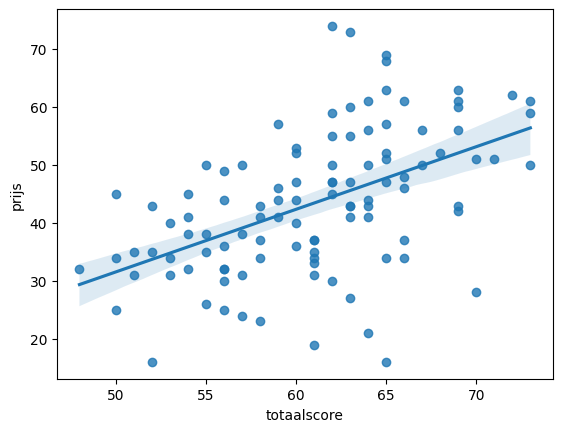

3. [2pt] Maak gebruik van lineaire regressie om te proberen de *prijs* te voorspellen op basis van de *totaalscore*. Geef de vergelijking van de regressierechte.

4. [1pt] Geef de geschatte *prijs* voor een *totaalscore* = 70.

5. [1pt] Bereken de correlatiecoëfficient (symbool + waarde).

6. [1pt] Geef de interpretatie voor de waarde van de correlatiecoëfficient.

7. [1pt] Geef een overzicht van het aantal, minimum, maximum, gemiddelde, standaarddeviatie, ... in de kolommen met kwantitatieve variabelen.

8. [1pt] De variatiecoëfficiënt is een spreidingsmaat die onafhankelijk is van de eenheid waarin gegevens zijn uitgedrukt en wordt gedefinieerd als de standaarddeviatie gedeeld door het gemiddelde. Bereken de variatiecoëfficiënt voor *de score voor eten*.

9. [1pt] Hoeveel restaurants zijn er in New York City met een *prijs* hoger dan \$65 (\$65 niet inbegrepren)?

10. Zijn de *prijzen* in New York City significant ($\alpha = 0.05$) hoger dan in Long Island?

    - [0.5pt] Met welke statistische toets ga je dit bepalen?
    - [0.5pt] Formuleer de nulhypothese en de alternatieve hypothese
    - [1pt] Bereken de overschrijdingskans $p$
    - [1pt] Trek een besluit op basis van deze waarde en beantwoord de onderzoeksvraag.

In [16]:
dfrestaurants = pd.DataFrame(
    data={'naam': ["101","12th St. Bar & Grill","202 Café","212","24 Prince","26 Seats","360","41 Greenwich Avenue","44","44 X Hell's Kitchen","5 Ninth","71 Irving Place","718","A.O.C.","A.O.C. Bedford","Abboccato","Abigael's","Above","Adrienne's Pizzabar","Aesop's Tables","Agata & Valentina Ristorante","Agave","Agnanti","Aix Brasserie","Aja","Aji Sushi","Areo","Bouley, Upstairs","Casa Mono","Cesca","Coals","Etats-Unis","Gari","Henry's End","ino","inoteca","Joya","Lupa","MarkJoseph Steakhouse","Noodle Pudding","Norma's","Osaka","Pearl Oyster Bar","Piccola Venezia","Po","Scalinatella","Sparks Steak House","Spigolo","Sushi Ann","Sushi Sen-nin","Tommaso","Wolfgang's Steakhouse","Yakitori Totto","105 Harbor","1770 House Restaurant & Inn","25 East American Bistro","56th Fighter Group","Abel Conklin's","Adirondack Grill","Akbar","Albert's Mandarin Gourmet","Allison's Ristorante","Almond","Amici","Aqua Blue Bar & Grill","Argyle Grill & Tavern","Ariana","Ayhan's Fish Kebab","Ayhan's Mediterranean Café","B. Smith's","Baang Café & Bar","Babylon Carriage House","Bamboo Restaurant & Sushi","Barney's","Barolo","Basil Leaf Café","Bay & Main","Bayou, The","Bayport House, The","Bayview Inn & Restaurant","Beacon","Bedlam Street Fish & Clam","Bella Vita City Grill","Bellport, The","Benihana","Benny's Ristorante","Maureen & Daughters Kitchen","Minami","Mirko's","Nisen","Palm","Plaza Café","Robert's","Rothmann's Steakhouse","Royal Tangra Masala","Sempre Vivolo","Soigne","Sole","Starr Boggs","Steve's Piccola Bussola","Stonewalls","Tellers American Chophouse","Trattoria Diane","Vine Street Café","Vintage Prime Steakhouse","Yuki's Palette"],
    'locatie': ["NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","LI","LI","LI","LI","LI","LI","LI","LI","LI","LI","LI","LI","LI","LI","LI","LI","LI","LI","LI","LI","LI","LI","LI","LI","LI","LI","LI","LI","LI","LI","LI","LI","LI","LI","LI","LI","LI","LI","LI","LI","LI","LI","LI","LI","LI","LI","LI","LI","LI","LI","LI","LI","LI"],
    'eten': [20,21,21,17,18,23,23,18,20,21,20,19,22,19,23,23,20,18,24,22,18,19,24,21,20,21,25,25,25,23,25,25,26,25,24,23,25,25,25,25,25,25,26,25,25,25,25,25,25,25,25,25,25,20,24,16,14,22,16,19,23,19,21,22,18,21,20,20,18,16,22,21,20,26,24,18,19,22,21,24,20,22,21,24,17,25,25,25,25,25,25,25,25,25,25,25,25,25,25,25,25,25,25,25,25,25],
    'decor': [18,19,17,17,17,16,15,18,22,18,22,17,19,16,21,20,16,19,17,18,16,19,15,21,23,14,20,16,18,21,17,16,17,14,14,18,19,18,17,18,20,17,14,17,16,17,19,16,17,15,18,20,19,22,25,20,21,17,21,17,18,19,15,18,17,21,17,17,15,23,23,24,18,23,20,17,15,16,21,21,19,19,17,19,17,18,19,21,21,20,18,21,21,22,14,22,24,15,24,15,21,26,21,15,21,15],
    'service': [17,20,18,16,15,19,19,19,18,19,17,16,19,16,21,21,18,18,17,20,14,18,19,20,20,20,21,18,20,21,19,23,19,24,18,20,20,21,23,22,21,20,19,23,21,21,21,21,21,20,22,20,20,20,23,17,16,21,16,18,22,21,18,21,17,19,20,19,17,17,19,18,18,24,22,19,18,18,20,24,18,21,20,21,19,24,21,24,23,21,23,24,21,22,18,24,24,21,20,21,23,22,22,23,23,21],
    'prijs': [38,36,32,45,34,37,38,35,52,43,57,16,40,35,51,61,45,50,23,44,32,36,34,59,43,26,48,46,47,57,19,56,74,43,25,37,21,50,63,34,37,30,41,52,47,73,68,55,60,53,47,69,44,50,62,40,31,47,31,32,27,44,41,33,43,35,31,30,25,49,43,41,44,59,46,38,35,32,47,42,50,45,41,41,34,50,16,28,63,34,61,51,56,60,24,51,50,34,56,37,43,61,52,55,61,31]})

In [23]:
#1
dfrestaurants['totaalscore'] = dfrestaurants['eten'] + dfrestaurants['decor'] + dfrestaurants['service']

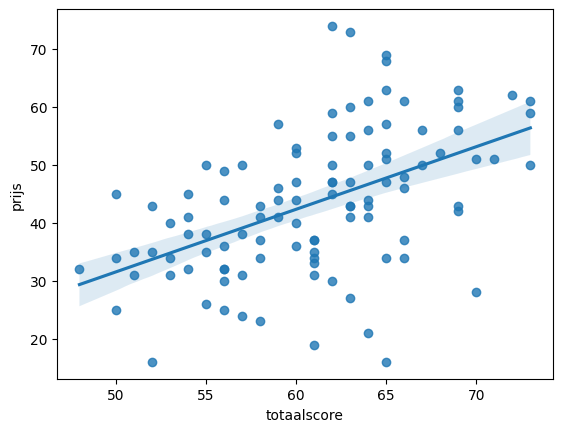

In [24]:
#2
sns.regplot(data = dfrestaurants, x = 'totaalscore', y = 'prijs');


In [29]:
#3
a,b = np.polyfit(dfrestaurants['totaalscore'], dfrestaurants['prijs'], deg=1)
print(f'y = {a:.4f} * x + {b:.4f}')

y = 1.0817 * x + -22.5688


In [32]:
#4
print(f'Prijds voor totaalscore = 70: {a * 70 + b:.4f}')

Prijds voor totaalscore = 70: 53.1513


In [34]:
#5
cor = np.corrcoef(dfrestaurants['totaalscore'], dfrestaurants['prijs'])[0][1]
print(f'R = {cor:.4f}')
# kwadraat cor -> print(f'R² = {cor ** 2}')

R = 0.5035


In [ ]:
#6 
#  betekent een positieve correlatie tussen de variabelen.
#  Dit geeft aan dat er een matig positieve relatie is tussen de totaalscore en de prijs.

In [35]:
#7
dfrestaurants.describe()

,eten,decor,service,prijs,totaalscore
count,106.000000,106.000000,106.000000,106.000000,106.000000
mean,22.471698,18.528302,19.990566,43.405660,60.990566
std,2.902241,2.712256,2.261459,12.411806,5.777617
min,14.000000,14.000000,14.000000,16.000000,48.000000
25%,20.000000,17.000000,18.000000,34.000000,56.250000
50%,23.500000,18.000000,20.000000,43.000000,61.500000
75%,25.000000,21.000000,21.000000,51.000000,65.000000
max,26.000000,26.000000,24.000000,74.000000,73.000000


In [38]:
#8
VarCof = dfrestaurants['eten'].std() / dfrestaurants['eten'].mean()
print(f'VariatieCoëfficiënt: {VarCof:.4f}')

VariatieCoëfficiënt: 0.1292


In [44]:
#9
dfrestaurants[(dfrestaurants.prijs > 65) & (dfrestaurants.locatie == 'NYC')]['naam'].count()


4

In [45]:
#10

stats.ttest_ind(
  a=dfrestaurants[dfrestaurants.locatie == 'LI']['prijs'],
  b=dfrestaurants[dfrestaurants.locatie == 'NYC']['prijs'],
  alternative='less', equal_var=False)

TtestResult(statistic=-0.585071488401949, pvalue=0.27990194701641724, df=101.04698869499992)

### Antwoord

1. 

2. 

3. 

4. 

5. 

6.  betekent een positieve correlatie tussen de variabelen. Dit geeft aan dat er een matig positieve relatie is tussen de totaalscore en de prijs.

7. 

8. 

9. 

10. 

----

## Vraag 9 [7 pt]

Hieronder staat de omzet van Wal-Mart per kwartaal (uitgedrukt in billion dollar)

1. [1pt] Converteer de 'datum' naar het datatype datetime en stel deze in als index.

2. [1pt] Maak de onderstaande plot.

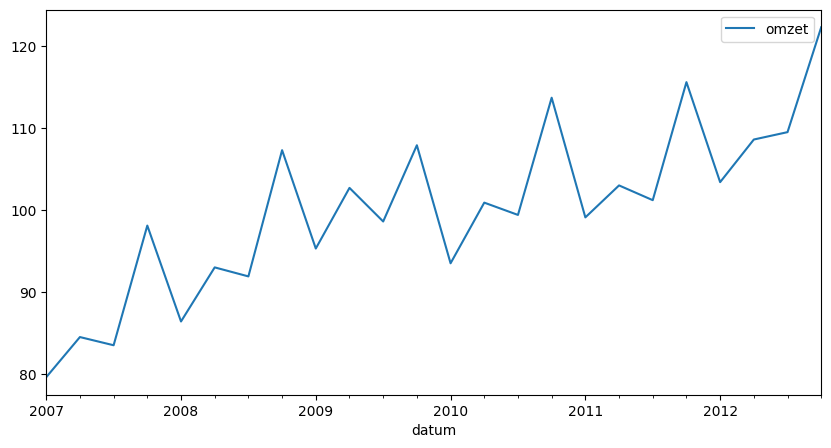

3. Maak een voorspelling voor de omzet van het volgende boekhoudkundige jaar met behulp van de meest geschikte methode. Leg uit waarom je deze methode hebt gekozen [1pt]. Geef ook de voorspelde waarden [1pt].

4. Maak een plot met de geobserveerde waarden, de door het model geschatte (*fitted*) waarden [1pt] en de voorspelling voor het volgende boekhoudkundige jaar [1pt].

5. [1pt] In welk kwartaal zal de omzet voor het eerst meer dan $150 billion bedragen?

In [73]:
dfwalmart = pd.DataFrame(data={
    'datum': ['2007/01/01', '2007/04/01', '2007/07/01', '2007/10/01', '2008/01/01', '2008/04/01', '2008/07/01', '2008/10/01','2009/01/01', '2009/04/01', '2009/07/01', '2009/10/01','2010/01/01', '2010/04/01', '2010/07/01', '2010/10/01','2011/01/01', '2011/04/01', '2011/07/01', '2011/10/01','2012/01/01', '2012/04/01', '2012/07/01', '2012/10/01'],
    'kwartaal': ['2007-1','2007-2','2007-3','2007-4','2008-1','2008-2','2008-3','2008-4','2009-1','2009-2','2009-3','2009-4','2010-1','2010-2','2010-3','2010-4','2011-1','2011-2','2011-3','2011-4','2012-1','2011-2','2011-3','2011-4'],
    'omzet': [79.6,84.5,83.5,98.1,86.4,93,91.9,107.3,95.3,102.7,98.6,107.9,93.5,100.9,99.4,113.7,99.1,103,101.2,115.6,103.4,108.6,109.5,122.3]
})
dfwalmart.head()

,datum,kwartaal,omzet
0,2007/01/01,2007-1,79.6
1,2007/04/01,2007-2,84.5
2,2007/07/01,2007-3,83.5
3,2007/10/01,2007-4,98.1
4,2008/01/01,2008-1,86.4


In [74]:
#1
dfwalmart['datum'] = pd.to_datetime(dfwalmart['datum'])
dfwalmart.set_index('datum', inplace=True)


<Axes: xlabel='datum'>

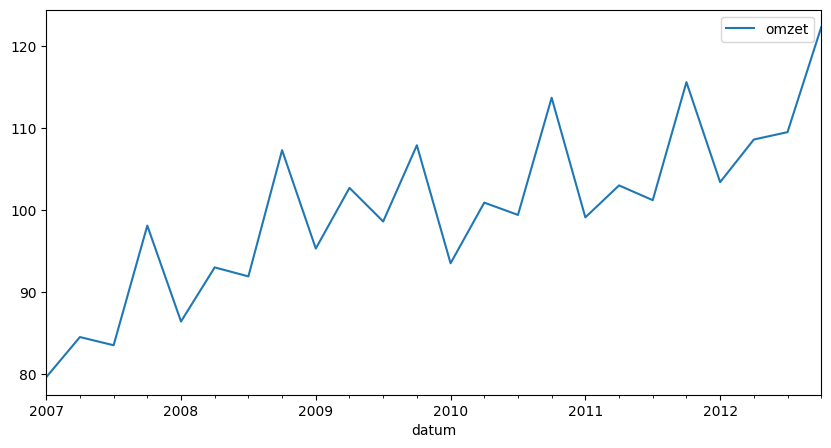

In [75]:
#2
dfwalmart.plot(y = 'omzet', figsize=[10,5])

In [77]:
#3
from statsmodels.tsa.holtwinters import ExponentialSmoothing
omzet_hw = ExponentialSmoothing(
  dfwalmart.omzet, trend='add', seasonal='add', seasonal_periods=4, freq='QS').fit()
omzet_fc = omzet_hw.forecast(steps=4)
omzet_fc

2013-01-01    109.320105
2013-04-01    115.220185
2013-07-01    113.786961
2013-10-01    127.253599
Freq: QS-JAN, dtype: float64

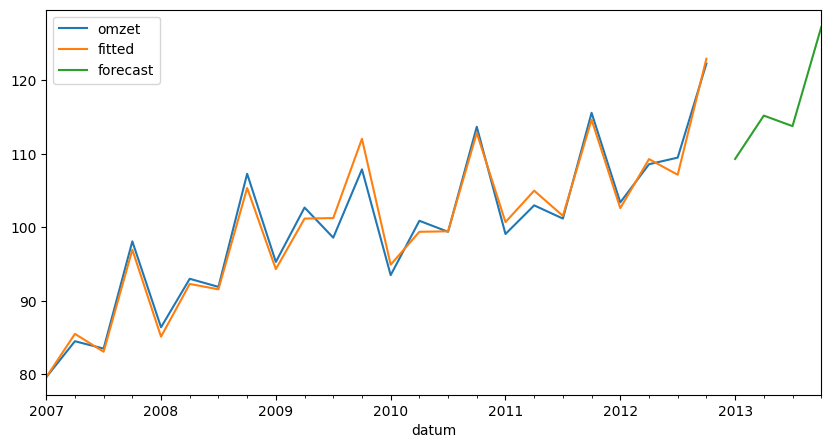

In [82]:
#4
dfwalmart.plot(legend=True, figsize=[10,5]);
omzet_hw.fittedvalues.plot(legend=True, label='fitted');
omzet_fc.plot(legend=True, label='forecast');

In [86]:
import pandas as pd

# 1. Zet de voorspellingen in een DataFrame
forecast_df = pd.DataFrame({
    'datum': omzet_fc.index,
    'voorspelling': omzet_fc.values
})

# 2. Zoek naar het eerste kwartaal waarbij de voorspelling meer dan $150 billion is
over_150_billion = forecast_df[forecast_df['voorspelling'] > 150]

# Print het resultaat
print("Eerste kwartaal waarbij de omzet meer dan $150 billion bedraagt:")
print(over_150_billion)

Eerste kwartaal waarbij de omzet meer dan $150 billion bedraagt:
Empty DataFrame
Columns: [datum, voorspelling]
Index: []


### Antwoord

1. 

2. 

3. 



4. 


5. 

----

## Vraag 10 [4 pt] 

Een handelaar verhuurt industriële hogedrukreinigers. De vraag per dag naar deze toestellen kan als volgt worden beschreven:

| _x_      | 0    |    1 |    2 |    3 |
| :---     | :--- | :--- | :--- | :--- |
| _P(X=x)_ | 0.15 | 0.40 | 0.30 | 0.15 |

Het beschikbaar houden van zo'n toestel kost 300 EUR per dag, terwijl de huurprijs 700 EUR per dag is. De manager vraagt zich af wat het meest zal opbrengen: 2 toestellen of 3 toestellen per dag beschikbaar stellen.

1. Bepaal de kansfunctie voor:
   
    - [1pt] Kansvariabele _Y_, de winst wanneer er 2 toestellen beschikbaar zijn
    - [1pt] Kansvariabele _W_, de winst wanneer er 3 toestellen beschikbaar zijn

2. [1pt] Wat is de verwachte winst in beide gevallen? M.a.w. bereken $E[Y]$ en $E[W]$.
3. [1pt] Wat is de optimale keuze voor de handelaar?


In [ ]:
##zie wordbestand

# belangrijkste te onthouden:
# te betalenPerDag/toestel = 300
# krijgenPerDag/toestel = 700
# WinstPerDag = 400

| _Y_      | -600 |  100 |  800 |   
| :---     | :--- | :--- | :--- |
| _P(Y=y)_ | 0.15 | 0.40 | 0.45 | 


| _W_      | -900 | -200 |  500 | 1200 |
| :---     | :--- | :--- | :--- | :--- |
| _P(W=w)_ | 0.15 | 0.40 | 0.30 | 0.15 |

### Antwoord

1. E[Y] = -600 x 0.15 + 100 x 0.4 + 800 x 0.45 = 310,
   E[W] = -900 x 0.15 - 200 x 0.4 + 500 x 0.3 + 1200 x 0.15 = 115

2. De optimale keuze is dus 2 toestellen ter beschikking te stellen, ook al kan je niet altijd voldoen aan de vraag.